# 01 — Data Understanding: Kualitas Udara Lamongan

Notebook ini digunakan untuk memahami karakteristik awal dataset kualitas udara Kabupaten Lamongan sebelum tahap EDA dan time series.

**Sumber:** CAMS Global Atmospheric Composition Forecasts (Copernicus Atmosphere Data Store)

**Wilayah:** Kabupaten Lamongan, Jawa Timur

**Koordinat titik data:** latitude `-7.2`, longitude `112.4`

**Periode aktual:** 29 Agustus 2025 – 29 Agustus 2026

**Polutan:** PM1, PM2.5, PM10


## 1. Tujuan

Tahap Data Understanding bertujuan mengetahui ukuran dataset, struktur kolom, periode, lokasi, tipe data, missing value, duplikasi, nilai tidak valid, statistik deskriptif, dan outlier sebelum analisis lanjutan.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_PATH = '../data/data_lamongan_clean.csv'
df = pd.read_csv(DATA_PATH)
df['valid_time'] = pd.to_datetime(df['valid_time'], errors='coerce')
pollutants = ['pm1_ug_m3', 'pm2p5_ug_m3', 'pm10_ug_m3']

print(f'Ukuran dataset: {len(df):,} baris × {df.shape[1]} kolom')


Ukuran dataset: 1,464 baris × 6 kolom


## 2. Informasi Dataset


In [2]:
print('='*60)
print('INFORMASI DATASET')
print('='*60)
print(f'Jumlah baris : {df.shape[0]:,}')
print(f'Jumlah kolom : {df.shape[1]}')
print('\nKolom:')
for c in df.columns: print('-', c)
print('\n5 data pertama:')
display(df.head())
print('\n5 data terakhir:')
display(df.tail())


INFORMASI DATASET
Jumlah baris : 1,464
Jumlah kolom : 6

Kolom:
- valid_time
- latitude
- longitude
- pm1_ug_m3
- pm2p5_ug_m3
- pm10_ug_m3

5 data pertama:


,valid_time,latitude,longitude,pm1_ug_m3,pm2p5_ug_m3,pm10_ug_m3
0,2025-08-29 00:00:00,-7.200,112.400,58.889,64.675,67.464
1,2025-08-29 06:00:00,-7.200,112.400,23.508,26.348,27.369
2,2025-08-29 12:00:00,-7.200,112.400,78.598,84.529,86.252
3,2025-08-29 18:00:00,-7.200,112.400,76.834,83.164,85.729
4,2025-08-30 00:00:00,-7.200,112.400,84.052,90.816,93.775



5 data terakhir:


,valid_time,latitude,longitude,pm1_ug_m3,pm2p5_ug_m3,pm10_ug_m3
1459,2026-08-28 18:00:00,-7.200,112.400,32.469,36.573,38.829
1460,2026-08-29 00:00:00,-7.200,112.400,72.169,77.297,79.546
1461,2026-08-29 06:00:00,-7.200,112.400,24.200,28.542,30.601
1462,2026-08-29 12:00:00,-7.200,112.400,17.732,22.072,24.887
1463,2026-08-29 18:00:00,-7.200,112.400,24.888,28.733,30.978


## 3. Tipe Data


In [3]:
display(df.dtypes.to_frame('dtype'))
df.info()


,dtype
valid_time,datetime64[us]
latitude,float64
longitude,float64
pm1_ug_m3,float64
pm2p5_ug_m3,float64
pm10_ug_m3,float64


<class 'pandas.DataFrame'>
RangeIndex: 1464 entries, 0 to 1463
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   valid_time   1464 non-null   datetime64[us]
 1   latitude     1464 non-null   float64       
 2   longitude    1464 non-null   float64       
 3   pm1_ug_m3    1464 non-null   float64       
 4   pm2p5_ug_m3  1464 non-null   float64       
 5   pm10_ug_m3   1464 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 68.8 KB


## 4. Periode dan Lokasi


In [4]:
print('Mulai  :', df['valid_time'].min())
print('Selesai:', df['valid_time'].max())
print('Durasi :', df['valid_time'].max() - df['valid_time'].min())
print('Latitude unik :', df['latitude'].unique())
print('Longitude unik:', df['longitude'].unique())
print('Timestamp unik:', df['valid_time'].nunique())


Mulai  : 2025-08-29 00:00:00
Selesai: 2026-08-29 18:00:00
Durasi : 365 days 18:00:00
Latitude unik : [-7.2]
Longitude unik: [112.4]
Timestamp unik: 1464


## 5. Deskripsi Variabel

| Kolom | Keterangan | Satuan |
|---|---|---|
| `valid_time` | Waktu data | waktu |
| `latitude` | Lintang lokasi | derajat |
| `longitude` | Bujur lokasi | derajat |
| `pm1_ug_m3` | Particulate Matter ≤ 1 µm | µg/m³ |
| `pm2p5_ug_m3` | Particulate Matter ≤ 2.5 µm | µg/m³ |
| `pm10_ug_m3` | Particulate Matter ≤ 10 µm | µg/m³ |


## 6. Missing Value


In [5]:
missing = pd.DataFrame({'jumlah': df.isna().sum(), 'persentase': df.isna().mean()*100})
display(missing)
print('Total missing:', int(df.isna().sum().sum()))


,jumlah,persentase
valid_time,0,0.000
latitude,0,0.000
longitude,0,0.000
pm1_ug_m3,0,0.000
pm2p5_ug_m3,0,0.000
pm10_ug_m3,0,0.000


Total missing: 0


## 7. Duplikasi


In [6]:
print('Jumlah baris duplikat:', int(df.duplicated().sum()))


Jumlah baris duplikat: 0


## 8. Nilai Tidak Valid

Konsentrasi PM tidak boleh negatif secara fisik. Nilai negatif dipisahkan dari outlier statistik agar tidak langsung disimpulkan sebagai data salah hanya karena ekstrem.


In [7]:
invalid = pd.DataFrame(index=pollutants)
invalid['negative_count'] = [(df[c] < 0).sum() for c in pollutants]
invalid['negative_percent'] = [(df[c] < 0).mean()*100 for c in pollutants]
display(invalid)
print('Baris dengan minimal satu PM negatif:', int((df[pollutants] < 0).any(axis=1).sum()))


,negative_count,negative_percent
pm1_ug_m3,0,0.000
pm2p5_ug_m3,0,0.000
pm10_ug_m3,0,0.000


Baris dengan minimal satu PM negatif: 0


## 9. Statistik Deskriptif


In [8]:
stats = df[pollutants].describe().T
stats['median'] = df[pollutants].median()
stats = stats[['count','mean','median','std','min','max']]
display(stats)


,count,mean,median,std,min,max
pm1_ug_m3,"1,464.000",57.529,50.124,33.979,8.040,193.528
pm2p5_ug_m3,"1,464.000",62.028,53.589,35.869,10.248,204.640
pm10_ug_m3,"1,464.000",63.610,54.827,36.421,10.407,207.295


## 10. Deteksi Outlier dengan IQR

Outlier statistik dihitung dengan batas Q1 − 1.5×IQR dan Q3 + 1.5×IQR. Outlier tidak otomatis dihapus karena nilai ekstrem dapat mencerminkan kondisi polusi yang nyata.


In [9]:
rows=[]
for c in pollutants:
    q1=df[c].quantile(.25); q3=df[c].quantile(.75); iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr
    mask=(df[c]<lo)|(df[c]>hi)
    rows.append({'variable':c,'Q1':q1,'Q3':q3,'IQR':iqr,'batas_bawah':lo,'batas_atas':hi,'outlier_count':int(mask.sum()),'outlier_percent':mask.mean()*100})
outlier_summary=pd.DataFrame(rows)
display(outlier_summary)


,variable,Q1,Q3,IQR,batas_bawah,batas_atas,outlier_count,outlier_percent
0,pm1_ug_m3,29.858,78.798,48.939,-43.550,152.206,22,1.503
1,pm2p5_ug_m3,33.187,84.655,51.468,-44.015,161.857,22,1.503
2,pm10_ug_m3,34.235,86.409,52.174,-44.026,164.670,22,1.503


## 11. Distribusi Polutan


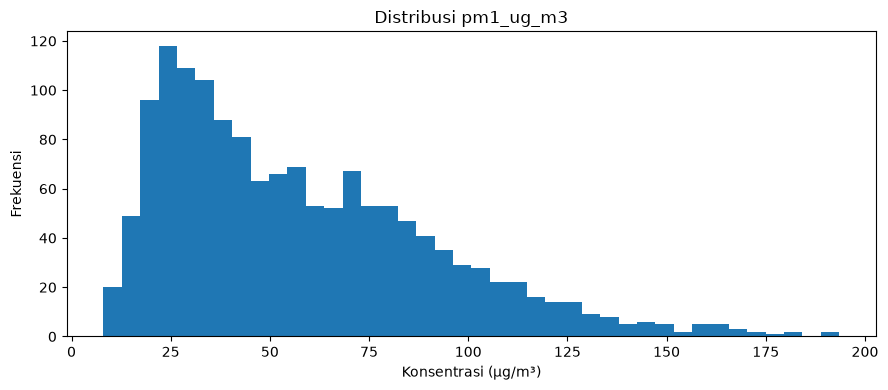

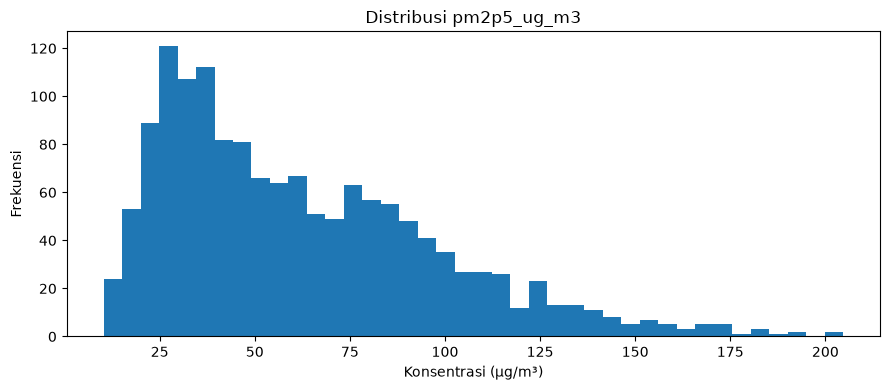

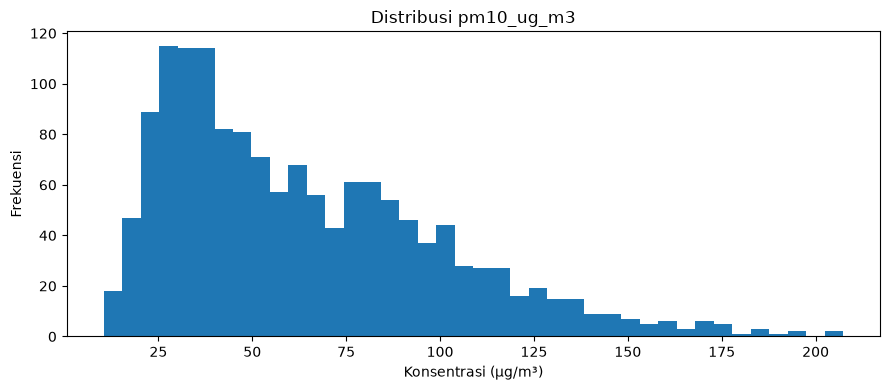

In [10]:
for c in pollutants:
    plt.figure(figsize=(9,4))
    plt.hist(df[c].dropna(), bins=40)
    plt.title(f'Distribusi {c}')
    plt.xlabel('Konsentrasi (µg/m³)')
    plt.ylabel('Frekuensi')
    plt.tight_layout()
    plt.show()


## 12. Boxplot


/tmp/ipykernel_35492/3705963827.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].dropna(), vert=False)


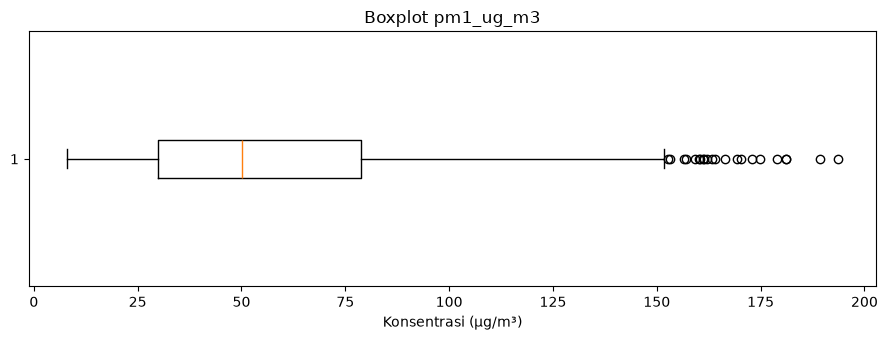

/tmp/ipykernel_35492/3705963827.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].dropna(), vert=False)


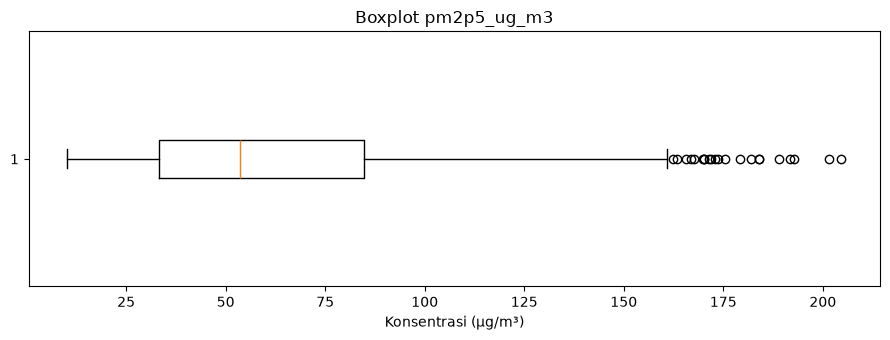

/tmp/ipykernel_35492/3705963827.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[c].dropna(), vert=False)


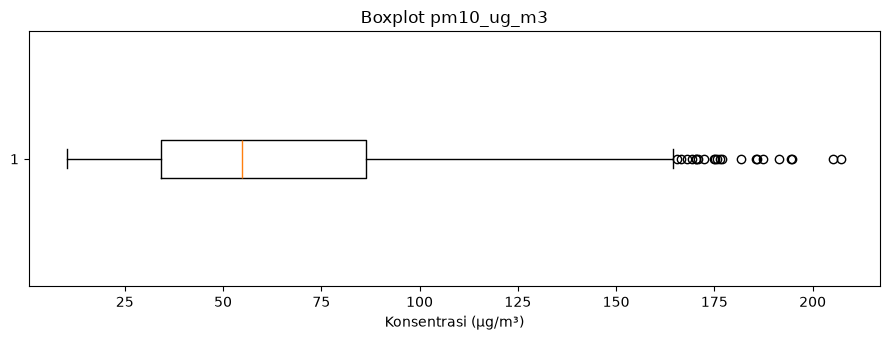

In [11]:
for c in pollutants:
    plt.figure(figsize=(9,3.5))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f'Boxplot {c}')
    plt.xlabel('Konsentrasi (µg/m³)')
    plt.tight_layout()
    plt.show()


## 13. Korelasi Antar Polutan


,pm1_ug_m3,pm2p5_ug_m3,pm10_ug_m3
pm1_ug_m3,1.000,0.999,0.998
pm2p5_ug_m3,0.999,1.000,0.999
pm10_ug_m3,0.998,0.999,1.000


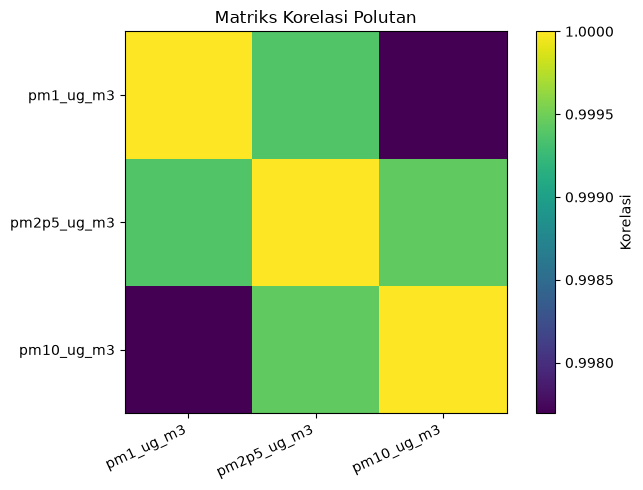

In [12]:
corr=df[pollutants].corr()
display(corr)
plt.figure(figsize=(7,5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar(label='Korelasi')
plt.xticks(range(len(pollutants)), pollutants, rotation=25, ha='right')
plt.yticks(range(len(pollutants)), pollutants)
plt.title('Matriks Korelasi Polutan')
plt.tight_layout()
plt.show()


## 14. Kesimpulan Data Understanding

Kesimpulan harus menggunakan angka hasil eksekusi notebook. Ringkas ukuran data, periode, koordinat, variabel, missing value, duplikasi, nilai negatif, outlier, dan kesiapan dataset untuk EDA/time series.


In [13]:
print('='*70)
print('RINGKASAN DATA UNDERSTANDING')
print('='*70)
print(f'Baris                 : {len(df):,}')
print(f'Kolom                 : {df.shape[1]}')
print(f'Periode               : {df.valid_time.min()} s/d {df.valid_time.max()}')
print(f'Koordinat             : {df.latitude.iloc[0]}, {df.longitude.iloc[0]}')
print(f'Missing value         : {int(df.isna().sum().sum()):,}')
print(f'Duplikasi             : {int(df.duplicated().sum()):,}')
print(f'Baris PM negatif      : {int((df[pollutants] < 0).any(axis=1).sum()):,}')
print('\nStatistik utama:')
display(df[pollutants].describe().T[['mean','50%','std','min','max']].rename(columns={'50%':'median'}))


RINGKASAN DATA UNDERSTANDING
Baris                 : 1,464
Kolom                 : 6
Periode               : 2025-08-29 00:00:00 s/d 2026-08-29 18:00:00
Koordinat             : -7.2, 112.4
Missing value         : 0
Duplikasi             : 0
Baris PM negatif      : 0

Statistik utama:


,mean,median,std,min,max
pm1_ug_m3,57.529,50.124,33.979,8.040,193.528
pm2p5_ug_m3,62.028,53.589,35.869,10.248,204.640
pm10_ug_m3,63.610,54.827,36.421,10.407,207.295


## 15. Status

Jika seluruh pemeriksaan sudah selesai, dataset siap digunakan untuk tahap berikutnya dengan catatan nilai PM negatif harus ditangani secara konsisten pada proses cleaning. Outlier statistik tidak dihapus otomatis.

**Tahap berikutnya: Exploratory Data Analysis (EDA) dan analisis time series.**
